<a href="https://colab.research.google.com/github/prince-musonda/my-journey-to-artificial-intelligence/blob/main/FashionMnist_2_0_binary_classififcation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
from torchvision import transforms as T
from torch import nn

In [2]:
torch.manual_seed(42)
image_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.5],std=[0.5])
])

In [3]:
train_set = torchvision.datasets.FashionMNIST(root=".", train=True, download=True,transform=image_transform)


100%|██████████| 26.4M/26.4M [00:01<00:00, 15.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 267kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.95MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.4MB/s]


In [4]:
test_set = torchvision.datasets.FashionMNIST(root=".",download=True, train=False,transform=image_transform)

In [16]:
test_set.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

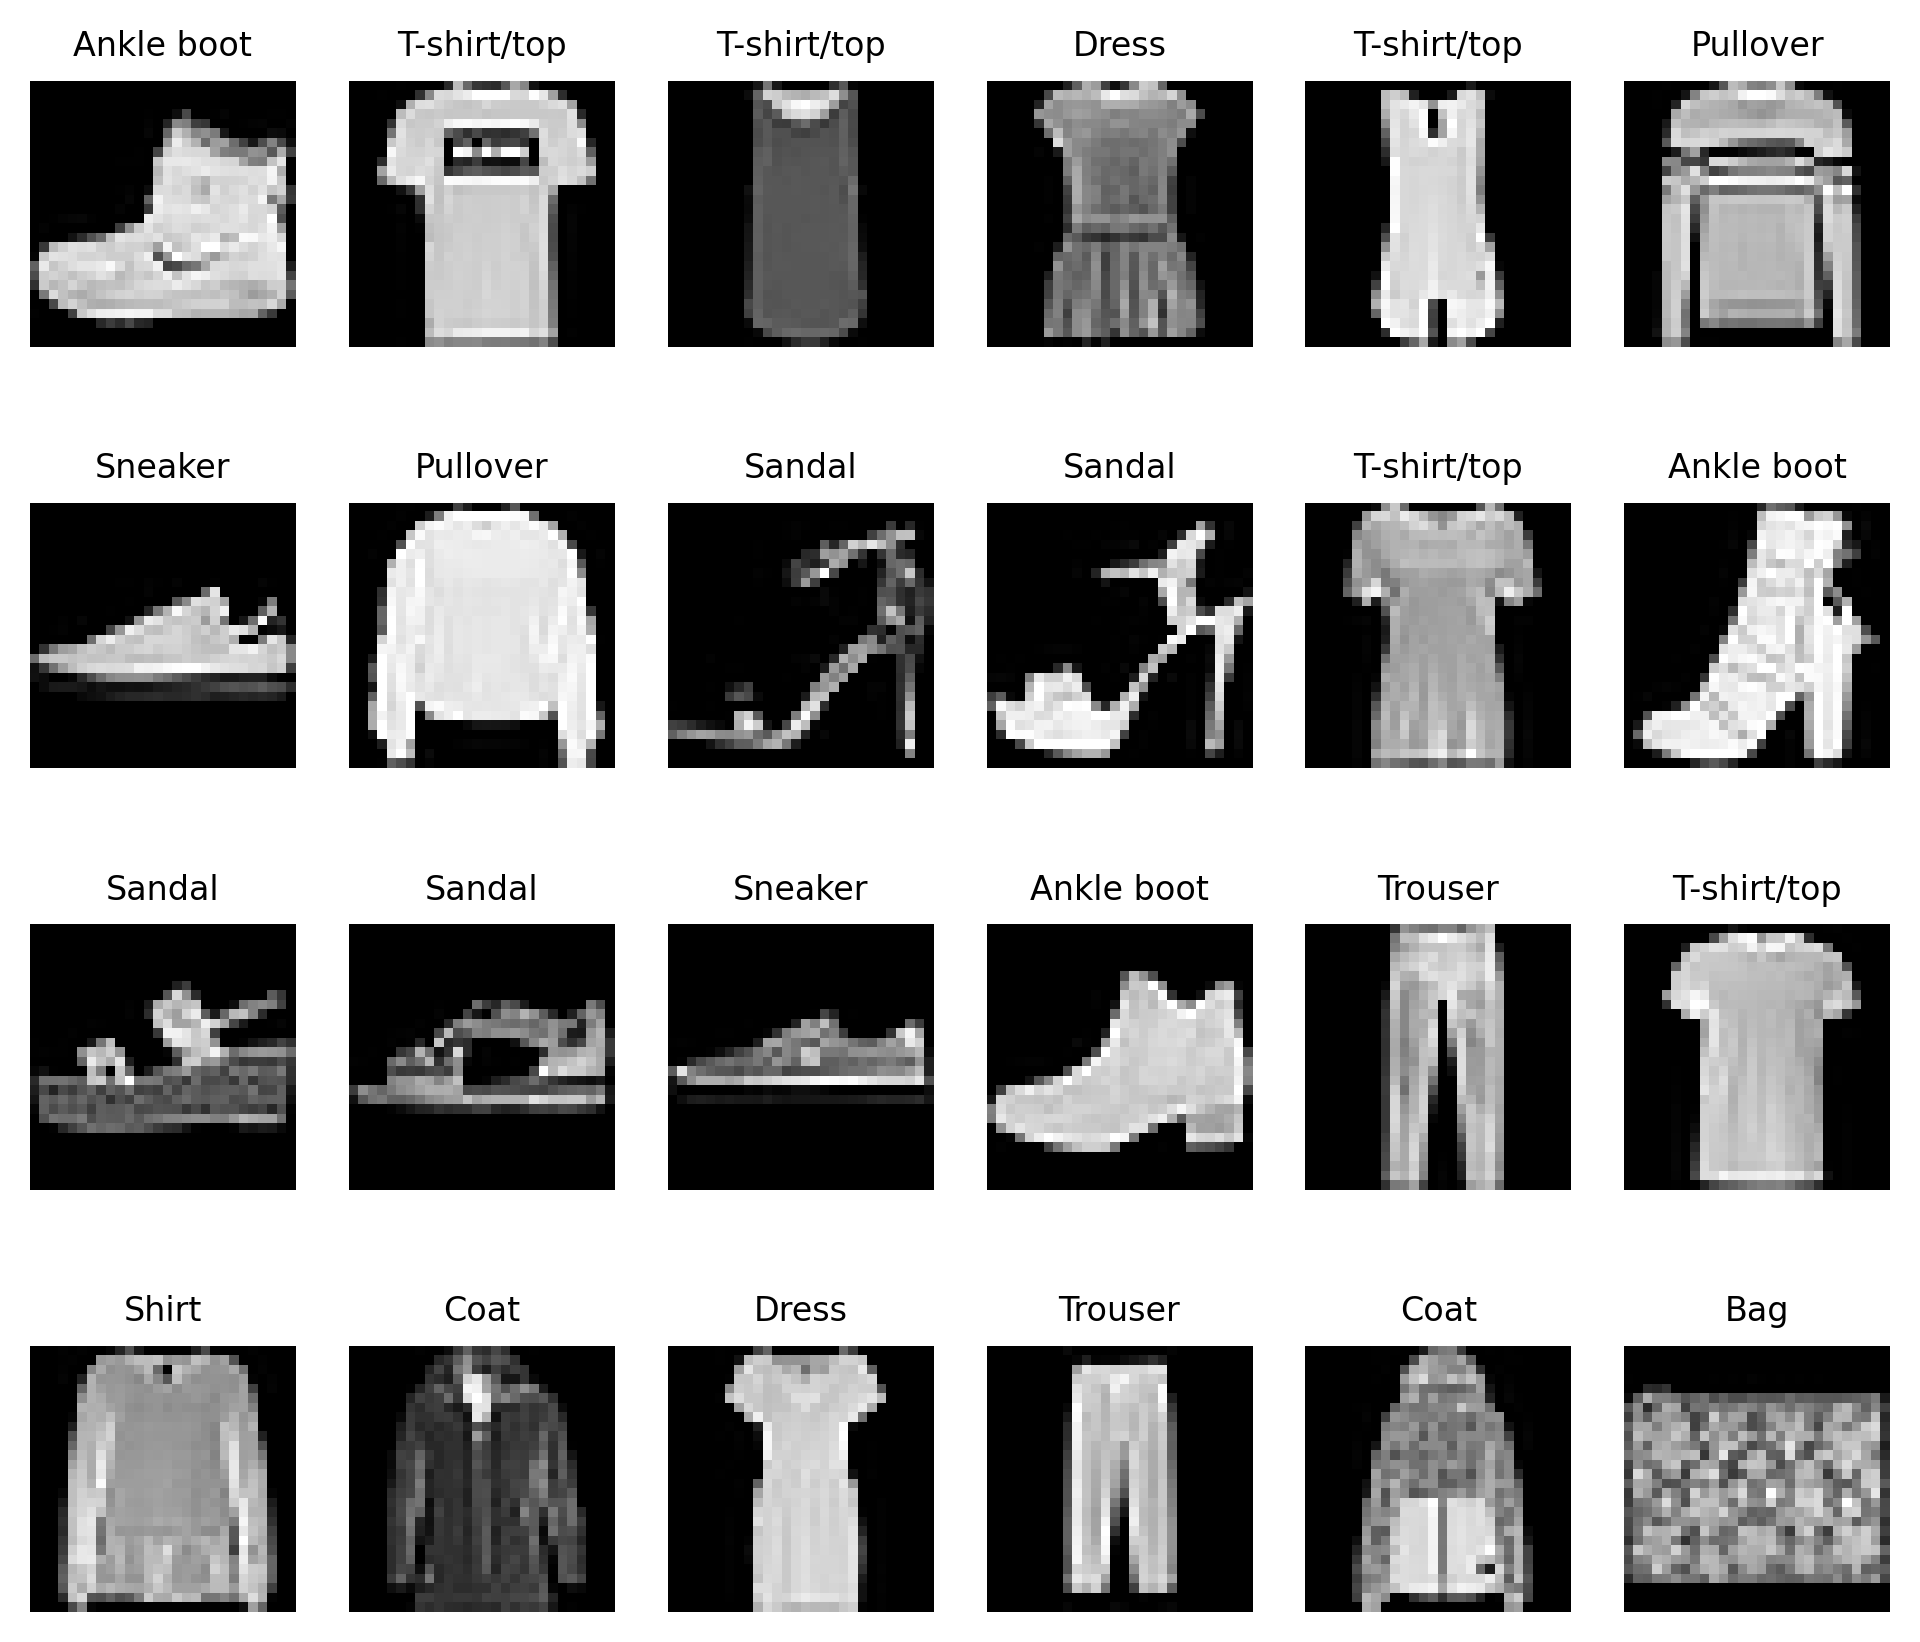

In [15]:
plt.figure(dpi=300, figsize=(8,7))
# view the first 24 images
for i in range(24):
  image = train_set[i][0]
  label_index = train_set[i][1]
  label_text = train_set.classes[label_index]
  # change image values from [-1, 1] to [0,1]
  image = (image * 0.5) + 0.5
  # plot the image
  plt.subplot(4,6, i + 1)
  plt.imshow(image.squeeze(),cmap="gray")
  plt.axis("off")
  plt.title(label_text, fontsize=8)

plt.show()

# **Binary classification of T-shirts and ankle boots**

In [17]:
binary_train_set = [x for x in train_set if x[1] in [0,9]]
binary_test_set = [x for x in test_set if x[1] in [0,9]]

In [25]:
# create batch

batch_size = 32
binary_train_data_loader = torch.utils.data.DataLoader(binary_train_set,
                                                       batch_size=batch_size,
                                                       shuffle=True)
binary_test_data_loader = torch.utils.data.DataLoader(binary_test_set,
                                                       batch_size=batch_size,
                                                       shuffle=False)


In [26]:
# create model

device = "cuda" if torch.cuda.is_available() else "cpu"

binary_model = nn.Sequential(
    nn.Linear(28*28, 256),
    nn.ReLU(),
    nn.Linear(256,32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Dropout(p=0.25),
    nn.Sigmoid()
).to(device)

In [27]:
# define optimizer and loss function
optimizer = torch.optim.Adam(binary_model.parameters(),0.001)
loss_fn = nn.BCELoss()

In [38]:
# training loop

for i in range(50):
  tloss = 0
  for img,label in binary_train_data_loader:
    img = img.reshape((-1,28*28)).to(device)
    label = torch.tensor([0 if x==0 else 1 for x in label],dtype=torch.float).to(device)
    label = label.reshape(-1,1)
    pred = binary_model(img)
    loss = loss_fn(pred, label)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    tloss += loss.item()
  tloss /= batch_size
  print(f"Epoch: {i} Loss: {tloss}")




Epoch: 0 Loss: 2.012428609887138
Epoch: 1 Loss: 2.0070134261623025
Epoch: 2 Loss: 1.954891954548657
Epoch: 3 Loss: 2.0273203852120787
Epoch: 4 Loss: 2.061842315643921
Epoch: 5 Loss: 1.9826447537634522
Epoch: 6 Loss: 2.0076900590211153
Epoch: 7 Loss: 2.051011776085943
Epoch: 8 Loss: 2.0219049570150673
Epoch: 9 Loss: 2.046950357267633
Epoch: 10 Loss: 2.0672573728952557
Epoch: 11 Loss: 2.0103976521641016
Epoch: 12 Loss: 1.9806139648426324
Epoch: 13 Loss: 1.9921212969347835
Epoch: 14 Loss: 1.9697835203260183
Epoch: 15 Loss: 2.051011699717492
Epoch: 16 Loss: 2.005659306421876
Epoch: 17 Loss: 2.0462734061293304
Epoch: 18 Loss: 2.0205511460080743
Epoch: 19 Loss: 2.0374736663652584
Epoch: 20 Loss: 2.091625795001164
Epoch: 21 Loss: 2.015135918278247
Epoch: 22 Loss: 2.0110745052807033
Epoch: 23 Loss: 2.034089155495167
Epoch: 24 Loss: 2.076057049445808
Epoch: 25 Loss: 2.075380149297416
Epoch: 26 Loss: 2.0070130904205143
Epoch: 27 Loss: 2.0591345098800957
Epoch: 28 Loss: 2.054396198131144
Epoch: 2

**calculate accuracy on test data**

In [79]:
import numpy as np

results = []
for images, labels in binary_test_data_loader:
  images = images.reshape(-1,28*28).to(device)
  labels = labels.reshape(-1,1).to(device)
  preds = binary_model(images)
  # convert preditions to either 0 or 1 if pred < 0.5
  pred01 = torch.where(preds > 0.5, 1, 0)
  labels = torch.where(labels == 9, 1, 0)
  # calulate accuracy
  correct = (pred01 == labels ).cpu().numpy().mean()
  results.append(correct)
accuracy = np.array(results).mean()
print(f"Accuracy: {accuracy}")

Accuracy: 0.9990079365079365


In [80]:
print(results)

[np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.96875), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.96875), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.fl